# PotentialBank v1 — walkthrough

A runnable, **AiiDA-free** tour of the frozen **PotentialBank v1** artifact for reviewers/users opening this
repo. It uses only the committed/packaged artifacts (manifest, tables, advisor index) — **no** AiiDA DB, HPC,
daemon, raw potential files, or Materials Project API.

**Frozen headline (verified from artifacts in the next cells):**
- **237 unique certified donors** / **238 certified nodes** (1 recorded historical byte-duplicate);
- **8 families**;
- **33 F2-eligible materials** (≥2 independent certified donors).

**Scope (kept throughout):** certified *same-structure* donor reuse only — **no cross-material transfer**, **no
guaranteed acceleration**; CPA/BdG are out of scope for PotentialBank v1.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "reports" / "potentialbank_v1" / "potentialbank_v1_summary.json").exists():
            return cand
    raise FileNotFoundError("repo root not found (run from repo root or notebooks/)")

ROOT = find_repo_root()
PB   = ROOT / "reports" / "potentialbank_v1"
ADV  = ROOT / "src" / "kkr_convergence_advisor" / "data"
print("repo root:", ROOT)
print("bundle   :", PB.relative_to(ROOT))
print("advisor  :", ADV.relative_to(ROOT))

repo root: /Users/hemmati/JupyterHub/jbox/Paper/My_ML_cc/git/kkr_ml_tools
bundle   : reports/potentialbank_v1
advisor  : src/kkr_convergence_advisor/data


## 2. Load the packaged artifacts

In [2]:
manifest = pd.read_csv(PB / "potentialbank_v1_manifest.csv")
summary  = json.load(open(PB / "potentialbank_v1_summary.json"))
cov_fam  = pd.read_csv(PB / "tables" / "coverage_by_family.csv")
cov_cc   = pd.read_csv(PB / "tables" / "coverage_by_compat.csv")
warmst   = pd.read_csv(PB / "tables" / "warmstart_synthesis.csv")
parked   = pd.read_csv(PB / "tables" / "deferred_parked.csv")
adv_idx  = json.load(open(ADV / "advisor_index_v1.json"))
adv_tips = json.load(open(ADV / "advisor_example_tips_v1.json"))
print("manifest rows        :", len(manifest))
print("coverage_by_family   :", len(cov_fam), "families")
print("coverage_by_compat   :", len(cov_cc), "compat classes")
print("warmstart_synthesis  :", len(warmst), "rows")
print("deferred_parked      :", len(parked), "hard cases")
print("advisor index mats   :", len(adv_idx["materials"]), "| example tips:", len(adv_tips["tips"]))

manifest rows        : 237
coverage_by_family   : 8 families
coverage_by_compat   : 42 compat classes
warmstart_synthesis  : 15 rows
deferred_parked      : 9 hard cases
advisor index mats   : 35 | example tips: 8


## 3. Manifest overview (counts + fields + duplicate-sha check)

In [3]:
# headline numbers straight from the summary artifact, cross-checked against the manifest
nodes  = summary["certified_donor_nodes"]
unique = summary["unique_sha_donors"]
fams   = len(summary["by_family"])
f2     = summary["f2_eligible_material_count"]
print(f"certified donor nodes : {nodes}")
print(f"unique-sha donors     : {unique}")
print(f"families              : {fams}")
print(f"F2-eligible materials : {f2}")
print(f"compat classes        : {manifest['compat_class'].nunique()}")

# verify the frozen headline (loaded, not blindly hardcoded)
assert unique == manifest["sha256"].nunique() == 237, "unique donor count mismatch"
assert nodes == 238 and fams == 8 and f2 == 33, "headline mismatch"
print("\nHEADLINE VERIFIED from artifacts: 237 unique / 238 nodes / 8 families / 33 F2-eligible")

certified donor nodes : 238
unique-sha donors     : 237
families              : 8
F2-eligible materials : 33
compat classes        : 42

HEADLINE VERIFIED from artifacts: 237 unique / 238 nodes / 8 families / 33 F2-eligible


In [4]:
# key fields (one row per certified donor)
print("columns:", list(manifest.columns))
manifest[["source_stage","family","material","sha256","z_sequence","natyp",
          "nspin","soc","lmax","compat_class","empty_sphere","f2_eligible"]].head(8)

columns: ['source_stage', 'family', 'material', 'formula', 'seg_pk', 'wc_pk', 'uuid', 'sha256', 'z_sequence', 'natyp', 'nspin', 'soc', 'lmax', 'compat_class', 'empty_sphere', 'cpa', 'bdg', 'final_rms', 'integrity_ok', 'roundtrip_ok', 'f2_eligible']


,source_stage,family,material,sha256,z_sequence,natyp,nspin,soc,lmax,compat_class,empty_sphere,f2_eligible
0,E1,E1_NbSe2_Bi,Bi16X8,40906698e6999b5b20d20b2135fd76fb515a380dca834a...,"[0, 0, 0, 0, 83, 83, 83, 83, 83, 83, 83, 83, 8...",24,2.0,True,3.0,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",False,False
1,E1,E1_NbSe2_Bi,Nb2Se4X2,486c86875ca4e22cc1ce53c8add054f8ab825bab7e303c...,"[41, 41, 34, 34, 34, 34, 0, 0]",8,2.0,False,2.0,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",False,True
2,E1,E1_NbSe2_Bi,Bi14X4,123b79cd6c909337971c62ba10a6fefa2182c8980d3305...,"[0, 0, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83,...",18,2.0,False,3.0,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",False,True
3,E1,E1_NbSe2_Bi,Bi4X4,2a87309909c44269126a9929d4946bd44a8700d5b62fc0...,"[0, 0, 83, 83, 83, 83, 0, 0]",8,2.0,True,3.0,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",False,True
4,E1,E1_NbSe2_Bi,Bi4X4,3be8be98b83a3e9171787a403307df2bd3b8df462045a2...,"[0, 0, 83, 83, 83, 83, 0, 0]",8,2.0,True,3.0,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",False,True
5,E1,E1_NbSe2_Bi,Nb2Se4X2,f9a893dda8301f6f49c5f769f4dd73e0dbb5bd6f8a5b9c...,"[41, 41, 34, 34, 34, 34, 0, 0]",8,2.0,False,2.0,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",False,True
6,E1,E1_NbSe2_Bi,Nb2Se4X2,765a9f1979a0ebefcb0e1fd21ba81bc2845ffcbc816bfb...,"[41, 41, 34, 34, 34, 34, 0, 0]",8,2.0,False,2.0,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",False,True
7,E1,E1_NbSe2_Bi,Bi2X6,a7df24ad47c8d4975836d6e054904e9e4c3b69292c7de3...,"[0, 0, 0, 83, 83, 0, 0, 0]",8,2.0,True,3.0,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",False,True


**Field meanings.** `sha256` = byte-exact potential fingerprint (dedup key); `z_sequence`/`natyp` = per-site
atomic numbers (empty spheres as Z=0) and site count; `nspin`/`soc`/`lmax` = spin/SOC/angular settings;
`empty_sphere` = whether explicit vacant spheres are used (Si/Ge only); `compat_class` = the settings class a
donor is reusable within; `source_stage` = which campaign stage certified it; `f2_eligible` = the material has
≥2 independent donors. (`seg_pk`/`wc_pk`/`uuid` in the CSV are the AiiDA provenance handles — the raw
potentials live in the AiiDA repository, not here.)

In [5]:
# duplicate-sha check: 238 nodes vs 237 unique -> exactly one recorded historical byte-duplicate
print("duplicate_sha_excluded (summary):", summary["duplicate_sha_excluded"])
print("detail:", summary["duplicate_detail"])
dups = manifest["sha256"].value_counts()
print("\nany duplicate sha WITHIN the deduped manifest?:", (dups > 1).any(), "(expected False — the historical dup was collapsed)")

duplicate_sha_excluded (summary): 1
detail: E1 Bi2X4 pk 24009==24011 sha 0fe18594 (byte-identical; 1 excluded) -> 238 nodes = 237 unique

any duplicate sha WITHIN the deduped manifest?: False (expected False — the historical dup was collapsed)


## 4. Coverage by family and compatibility class

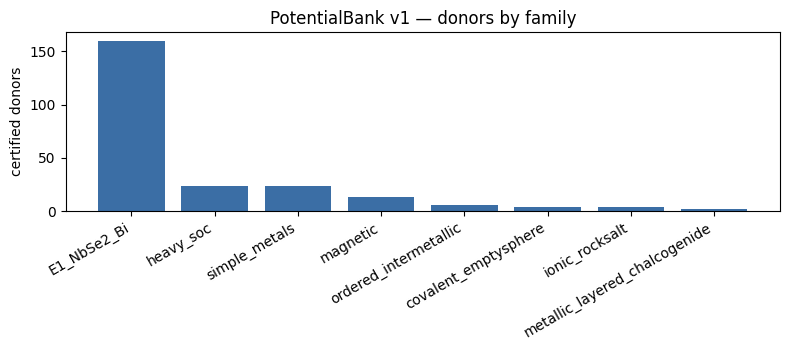

,family,n_donors,n_materials,n_f2_eligible,empty_sphere
0,E1_NbSe2_Bi,160,14,12,False
2,heavy_soc,24,5,5,False
7,simple_metals,24,5,5,False
4,magnetic,13,3,3,False
6,ordered_intermetallic,6,3,3,False
1,covalent_emptysphere,4,2,2,True
3,ionic_rocksalt,4,2,2,False
5,metallic_layered_chalcogenide,2,1,1,False


In [6]:
fam = cov_fam.sort_values("n_donors", ascending=False)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(fam["family"], fam["n_donors"], color="#3b6ea5")
ax.set_ylabel("certified donors"); ax.set_title("PotentialBank v1 — donors by family")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
fam[["family","n_donors","n_materials","n_f2_eligible","empty_sphere"]]

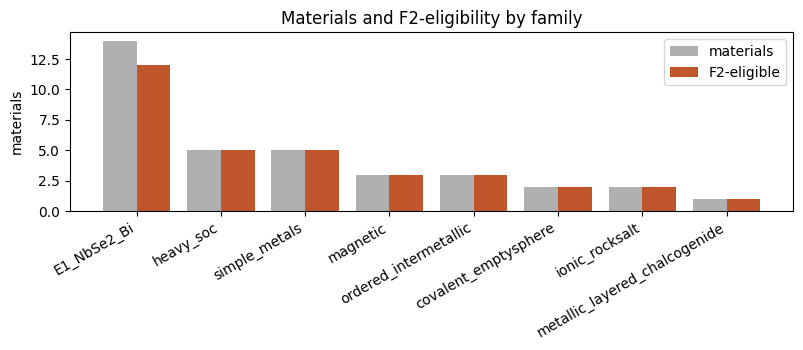

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = range(len(fam))
ax.bar([i-0.2 for i in x], fam["n_materials"], 0.4, label="materials", color="#b0b0b0")
ax.bar([i+0.2 for i in x], fam["n_f2_eligible"], 0.4, label="F2-eligible", color="#c0562c")
ax.set_xticks(list(x)); ax.set_xticklabels(fam["family"], rotation=30, ha="right")
ax.set_ylabel("materials"); ax.set_title("Materials and F2-eligibility by family"); ax.legend()
plt.tight_layout(); plt.show()

In [8]:
# coverage by compatibility class (top classes)
cov_cc.sort_values("n_donors", ascending=False).head(12)

,compat_class,n_donors,families
8,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",51,E1_NbSe2_Bi
5,nspin2_lmax3_soc1,24,heavy_soc
2,nspin1_lmax3_soc0,21,ordered_intermetallic|simple_metals
4,nspin2_lmax3_soc0,17,magnetic|ordered_intermetallic
15,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",15,E1_NbSe2_Bi
0,nspin1_lmax2_soc0,9,ionic_rocksalt|simple_metals
34,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",8,E1_NbSe2_Bi
23,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",7,E1_NbSe2_Bi
18,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",6,E1_NbSe2_Bi
31,"{""code_family"": ""standard"", ""nspin"": 2, ""soc"":...",6,E1_NbSe2_Bi


## 5. Certification rules (E1) — plain language

A potential is admitted as a donor only if **all** hold:
1. the **AiiDA-retrieved, staged, and manifest SHA-256 all agree** (3-way match);
2. the **parser succeeds** and the potential **byte-exactly round-trips**;
3. the per-type **Z-sequence matches the structure site order** and **NATYP == number of sites** (empty
   spheres encoded as Z=0);
4. the cell is **non-CPA and non-BdG**;
5. NSPIN / SOC / LMAX / mesh parse and there is **no guessed mapping** (unsafe → rejected).

CPA/disordered and BdG are excluded by construction. Below are real certified rows (we display manifest
metadata only — we do **not** open raw potential files).

In [9]:
examples = ["MgO","NaCl","Si","Ge","TiSe2"]
ex = manifest[manifest["material"].isin(examples)].drop_duplicates(["material","sha256"])
ex[["family","material","z_sequence","natyp","nspin","soc","lmax","empty_sphere","compat_class",
    "cpa","bdg","f2_eligible","sha256"]].reset_index(drop=True)

,family,material,z_sequence,natyp,nspin,soc,lmax,empty_sphere,compat_class,cpa,bdg,f2_eligible,sha256
0,covalent_emptysphere,Si,"[14, 14, 0, 0]",4,1.0,False,2.0,True,nspin1_lmax2_soc0_emptysphere,False,False,True,0f3913cc1b1ab178a0fc471ff8f0dd1dc7a0c98ae650db...
1,covalent_emptysphere,Si,"[14, 14, 0, 0]",4,1.0,False,2.0,True,nspin1_lmax2_soc0_emptysphere,False,False,True,516cb5bf448338748b011c2af9ea018f926e8aba6fcff0...
2,covalent_emptysphere,Ge,"[32, 32, 0, 0]",4,1.0,False,2.0,True,nspin1_lmax2_soc0_emptysphere,False,False,True,b42ccd6e89b58f659e4a1e6a1867e12e262a0b3db32f08...
3,covalent_emptysphere,Ge,"[32, 32, 0, 0]",4,1.0,False,2.0,True,nspin1_lmax2_soc0_emptysphere,False,False,True,8fe7b1bb19cfe57e24ec3ecbfaf16a842ecaba20be3a74...
4,metallic_layered_chalcogenide,TiSe2,"[22, 34, 34]",3,NaN,False,NaN,False,nspin1_lmax3_soc0_layered,False,False,True,f2568fe88d21ca0479f9cf74731bca1bdaef8ccc3d7c4a...
5,metallic_layered_chalcogenide,TiSe2,"[22, 34, 34]",3,NaN,False,NaN,False,nspin1_lmax3_soc0_layered,False,False,True,07813af15159cbdba3b4efd8dd17dd2e72bb2f74897614...
6,ionic_rocksalt,MgO,"[12, 8]",2,1.0,False,2.0,False,nspin1_lmax2_soc0,False,False,True,917b3bea0e6511c7a4bfa767ba06fd095f7b2c4fdb5b3e...
7,ionic_rocksalt,MgO,"[12, 8]",2,1.0,False,2.0,False,nspin1_lmax2_soc0,False,False,True,1858f32c7b4360961bf343a9ed865b2308ca613edf5dc6...
8,ionic_rocksalt,NaCl,"[11, 17]",2,1.0,False,2.0,False,nspin1_lmax2_soc0,False,False,True,68ccf55e5ea22255156751cf60bbd3338d93cf611fc9a9...
9,ionic_rocksalt,NaCl,"[11, 17]",2,1.0,False,2.0,False,nspin1_lmax2_soc0,False,False,True,cb742fd6cb1753b2b03f89aec738201fe49ea557135795...


## 6. Warm-start benchmark

Injecting a certified donor as the start potential cuts iterations-to-converge (same-structure). Numbers are
read from `warmstart_synthesis.csv`. **Warm-start benchmark outputs are not themselves certified as donors.**

In [10]:
warmst[["family","material","cold_iters","warm_iters","saved","pct_saved","direction_symmetry","contour_caveat"]]

,family,material,cold_iters,warm_iters,saved,pct_saved,direction_symmetry,contour_caveat
0,E1_NbSe2,Nb2Se4X2,391 (median),~197 (median),~194 median,~50%,"8/9 faster (1 slower, pair5)",coarse->fine staging offset for 5/9 pairs
1,simple_metals,Al,66,4,62,94%,symmetric (F2b),clean fine->fine (F2c)
2,simple_metals,Cu,81,7,74,91%,symmetric,clean fine->fine
3,simple_metals,Ag,77,6,71,92%,symmetric,clean fine->fine
4,simple_metals,Mo,102,6,96,94%,symmetric,clean fine->fine
5,heavy_soc,Au/W/Pt/Sb/Pb,122-136,2-3,~127 median,~97%,forward (F2a); reverse skipped (chain1 warm-made),clean fine->fine
6,magnetic,Fe/Ni/Co,131-136,5-6,~126 median,~96%,symmetric both dir (F2b),clean fine->fine; moments basin-matched
7,covalent_emptysphere,Si,119,2,117,98%,symmetric (G4),clean fine->fine
8,covalent_emptysphere,Ge,117,3,114,97%,symmetric (G4),clean fine->fine
9,ordered_intermetallic,CuZn,132,5,127,96%,symmetric (I4),clean fine->fine (non-mag basin)


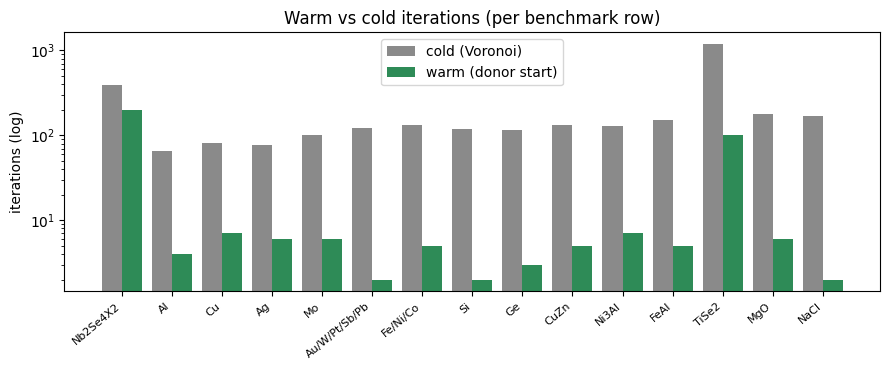

In [11]:
import re
def first_int(s):
    m = re.findall(r"[0-9]+", str(s).replace(",", "")); return int(m[0]) if m else None
w = warmst.copy()
w["cold1"] = w["cold_iters"].map(first_int); w["warm1"] = w["warm_iters"].map(first_int)
fig, ax = plt.subplots(figsize=(9, 3.8))
x = range(len(w))
ax.bar([i-0.2 for i in x], w["cold1"], 0.4, label="cold (Voronoi)", color="#8a8a8a")
ax.bar([i+0.2 for i in x], w["warm1"], 0.4, label="warm (donor start)", color="#2e8b57")
ax.set_yscale("log"); ax.set_xticks(list(x))
ax.set_xticklabels(w["material"], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("iterations (log)"); ax.set_title("Warm vs cold iterations (per benchmark row)"); ax.legend()
plt.tight_layout(); plt.show()

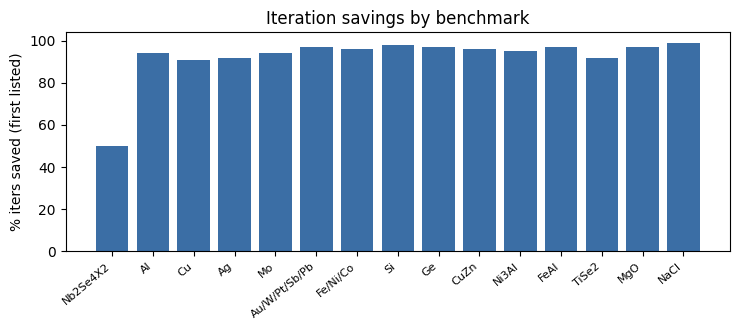

In [12]:
# percent saved
def first_pct(s):
    m = re.findall(r"[0-9]+", str(s)); return int(m[0]) if m else None
w["pct1"] = w["pct_saved"].map(first_pct)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(w["material"], w["pct1"], color="#3b6ea5")
ax.set_ylabel("% iters saved (first listed)"); ax.set_title("Iteration savings by benchmark")
plt.xticks(rotation=40, ha="right", fontsize=8); plt.tight_layout(); plt.show()

**Examples / caveats (read from the table above):**
- **MgO / NaCl** show the *mixing-path* effect: a Broyden target converges a warm start in a few iterations,
  while a pure-linear target still crawls (e.g. 500 vs 750) — hence the two numbers and the 33–99 % range.
- **Si / Ge** are covalent empty-sphere donors (~2–3 vs ~117–119 iters).
- **TiSe2** is coarse-converged only (its fine contour destabilizes the zero-gap semimetal) — a recorded
  contour caveat. Magnitude is mixing/contour-dependent, so we report per-family and never a single pooled
  headline.

## 7. Advisor index — optional, advisory-only tips

In [13]:
def advise(material):
    m = next((x for x in adv_idx["materials"] if x["material"] == material), None)
    if m is None:
        wobj = next((p for p in adv_idx["parked_warnings"] if p["material"] == material), None)
        return f"WARNING ({wobj['klass']}): {wobj['warning']}" if wobj else "no advice (not in bank)"
    if m.get("f2_eligible") and m.get("warmstart"):
        ws = m["warmstart"]
        return (f"donor_start (Level A): warm-start from a certified {material} donor; "
                f"measured {ws['warm']} vs {ws['cold']} iters ({ws['pct']}). caveat: {ws['contour_caveat']}")
    return f"{material}: {m['n_unique_donors']} certified donor(s); advisory only."

for mat in ["MgO", "NaCl", "Si", "Au", "WSe2", "MoS2"]:
    print(f"{mat:6s} -> {advise(mat)}\n")

MgO    -> donor_start (Level A): warm-start from a certified MgO donor; measured 6 (broyden) / 500 (linear) vs 178 (broyden) / 750 (linear) iters (97% / 33%). caveat: coarse; warm-vs-cold matched per mixing

NaCl   -> donor_start (Level A): warm-start from a certified NaCl donor; measured 2 (broyden) / 500 (linear) vs 171 (broyden) / 750 (linear) iters (99% / 33%). caveat: coarse; matched per mixing

Si     -> donor_start (Level A): warm-start from a certified Si donor; measured 2 vs 119 iters (98%). caveat: clean fine->fine

Au     -> Au: 5 certified donor(s); advisory only.

WSe2   -> WARNING (layered SOC chalcogenide): setup OK (NACLSD cleared @1.0) but SCF unstable (contour/EMIN, charge-neut bounces) + ~70min/iter; process paused 122051

MoS2   -> WARNING (layered chalcogenide): acute primitive AND conventional cell both NACLSD (1502/1615); layered stacking density



In [14]:
# the shipped worked example tips (each carries evidence level + confidence + reason)
pd.DataFrame(adv_tips["tips"])[["tip_type","material","evidence_level","confidence","recommendation"]]

,tip_type,material,evidence_level,confidence,recommendation
0,donor_start,MgO,A (exact structure),high,Warm-start from a certified MgO donor (sha 917...
1,donor_start,NaCl,A (exact structure),high,Warm-start from a certified NaCl donor (68ccf5...
2,donor_start,Si,A (exact structure),high,Warm-start from a certified Si donor (diamond ...
3,donor_start,TiSe2,A (exact structure),medium,Warm-start from a certified TiSe2 donor (coars...
4,donor_start,Fe/Ni/Co,A (exact structure),high,Warm-start magnetic runs from a certified Fe/N...
5,donor_start,Au/W/Pt/Sb/Pb (heavy-SOC),A (exact structure),high,Warm-start heavy-SOC runs from a certified don...
6,unsafe_warning,WSe2,parked,n/a,Do NOT expect a WSe2 donor: setup OK but SCF i...
7,unsafe_warning,MoS2,parked,n/a,Do NOT use the MP0 MoS2 cell (rhombohedral or ...


Tips are **advisory only** — a stock run ignores them; an opt-in run *may* inject the suggested certified
donor. The advisor never suggests a guessed/uncertified/CPA/BdG donor, and emits **warnings** (never "safe"
tips) for parked hard cases.

## 8. Deferred / parked hard cases (documented boundaries)

In [15]:
parked[["material","klass","stage","reason"]]

,material,klass,stage,reason
0,MoS2,layered chalcogenide,Stage S/T,acute primitive AND conventional cell both NAC...
1,WSe2,layered SOC chalcogenide,Stage S,setup OK (NACLSD cleared @1.0) but SCF unstabl...
2,NbS2,layered chalcogenide,Stage R,NACLSD solved @RCLUSTZ1.0 but donor won't conv...
3,TaS2,layered chalcogenide,Stage R,SOC removed NaN but SCF NaN-prone under broade...
4,TiAl,ordered intermetallic,Stage I5/I6,VERTEX3D tetragonal WS-vertex degeneracy; RCLU...
5,Bi2Te3,heavy-SOC compound,Stage F1n,"hard-convergence; 127 iters coarse rms 0.065, ..."
6,Bi2Se3,heavy-SOC compound,Stage MP,expected Bi2Te3-class hard-convergence; not at...
7,CaF2,ionic fluorite,Stage J0,needs octahedral empty sphere; deferred vs sim...
8,LiF,ionic rocksalt,Stage J0,no-ES OK but Z=3 very light + 8.7 eV gap; tert...


Failures are **useful**: each parked case is root-caused (NACLSD cluster overflow, SOC contour/EMIN
instability, tetragonal VERTEX3D shapefun degeneracy, hard-convergence, empty-sphere requirement), mapping out
where the method does and does not apply. None of these are certified donors.

## 9. Claim ladder (allowed / disallowed)

In [16]:
ladder = (PB / "PAPER_CLAIM_LADDER_AFTER_POTBANK_V1.md").read_text().splitlines()
def section(title):
    out, grab = [], False
    for ln in ladder:
        if ln.startswith("## "):
            grab = title.lower() in ln.lower()
            continue
        if grab and ln.strip().startswith(("-", "*")):
            out.append(ln.strip())
    return out
print("VALIDATED (excerpt):")
for ln in section("VALIDATED")[:3]: print("  ", ln)
print("\nDISALLOWED:")
for ln in section("DISALLOWED")[:6]: print("  ", ln)

VALIDATED (excerpt):
   - **PotentialBank v1 = 237 unique certified donors** (238 nodes, 1 E1 byte-dup) across **8 families / 35
   - **Same-structure warm-start gives large, reproducible iteration savings** on a converging target: 2–7 iters
   **direction-symmetric** where cold-comparable.

DISALLOWED:
   - **No cross-material transfer** — warm-start and the abort classifier do **not** transfer across materials
   - **No guaranteed acceleration** — savings depend on structure/mixing/contour; some cases park entirely.
   - **No broad layered / ionic / intermetallic "coverage"** — TiSe2 is the only certified layered chalcogenide;
   - **No CPA/doped/disordered or BdG donor claims** — excluded by construction from the certified bank.
   - **No "ML beats all baselines"** and **no 0.944 as a headline** — RMS@10 is a strong baseline; per-cohort
   - **MoS2/WSe2 "recovered"** — both parked (0 donors); only diagnoses/designs exist.


**Explicit scope reminders:**
- `ml_assist` early-abort **mechanism was validated live**, but **broad ML transfer was not proven** (it does
  not beat a simple RMS@10 baseline out-of-sample and does not transfer across materials).
- **PotentialBank v1 supports certified same-structure reuse.**
- **No cross-material transfer.**
- **No guaranteed acceleration.**

## 10. Reproducibility (checksums + version)

In [17]:
import hashlib
man = PB / "MANIFEST.sha256"
ver = PB / "VERSION"
if ver.exists():
    print("VERSION:"); print(json.dumps(json.load(open(ver)), indent=2))
if man.exists():
    ok = bad = 0
    for line in man.read_text().splitlines():
        sha, rel = line.split(None, 1); rel = rel.strip()
        p = ROOT / rel
        if not p.exists(): bad += 1; continue
        got = hashlib.sha256(p.read_bytes()).hexdigest()
        ok += (got == sha); bad += (got != sha)
    print(f"\nMANIFEST.sha256 verify: {ok} OK, {bad} mismatched/missing (of {ok+bad})")
else:
    print("MANIFEST.sha256 not present (bundle metadata not built)")
print("\nSummary: PotentialBank v1 =", summary["unique_sha_donors"], "unique certified donors across",
      len(summary["by_family"]), "families;", summary["f2_eligible_material_count"], "F2-eligible.",
      "Same-structure reuse only; no cross-material transfer; no guaranteed acceleration.")

VERSION:
{
  "name": "kkr_potentialbank_v1_synthesis",
  "version": "1.0",
  "frozen": "2026-08-11",
  "packaged": "2026-08-12",
  "git_commit": "5463ca0",
  "certified_donor_nodes": 238,
  "unique_sha_donors": 237,
  "families": 8,
  "f2_eligible_materials": 33,
  "manifest_sha256": "4186813d032f0db54434b418fe9e4f154b8c08025b0518f116ea604b464aab37",
  "note": "Same-structure warm-start reuse only; NOT cross-material transfer; CPA/BdG out of scope."
}

MANIFEST.sha256 verify: 22 OK, 0 mismatched/missing (of 22)

Summary: PotentialBank v1 = 237 unique certified donors across 8 families; 33 F2-eligible. Same-structure reuse only; no cross-material transfer; no guaranteed acceleration.
